<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
print(df.info())
print(df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None
          ResponseId                      MainBranch              Age  \
count   65437.000000                           65437            65437   
unique           NaN                               5                8   
top              NaN  I am a developer by profession  25-34 years old   
freq             NaN                           50207            23911   
mean    32719.000000                             NaN              NaN   
std     18890.179119                             NaN              NaN   
min         1.000000                             NaN              NaN   
25%     16360.000000                             NaN              NaN   
50%     32719.000000                             NaN              NaN   
75%     49078.000000                             NaN              NaN   
max     65437.000000  

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [7]:
print(df.isnull().sum())
df.dropna(subset=['JobSat', 'Employment'])
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'])
df['YearsCodePro'].fillna(df['YearsCodePro'].median())

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork                 9
                       ...  
JobSatPoints_11          117
SurveyLength             406
SurveyEase               374
ConvertedCompYearly    13051
JobSat                     0
Length: 114, dtype: int64


10        8.0
12       12.0
15       27.0
18       10.0
20        8.0
         ... 
65178    17.0
65241    10.0
65265     2.0
65351     7.0
65412    18.0
Name: YearsCodePro, Length: 29126, dtype: float64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [10]:
print(df['Employment'].value_counts())
print(df['JobSat'].value_counts())
print(df['YearsCodePro'].value_counts().head())

Employment
Employed, full-time                                                                                                               22537
Employed, full-time;Independent contractor, freelancer, or self-employed                                                           2291
Independent contractor, freelancer, or self-employed                                                                               1245
Employed, part-time                                                                                                                 534
Employed, full-time;Student, part-time                                                                                              509
                                                                                                                                  ...  
Employed, full-time;Not employed, but looking for work;Not employed, and not looking for work;Employed, part-time                     1
Student, full-time;Not employed, but 

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


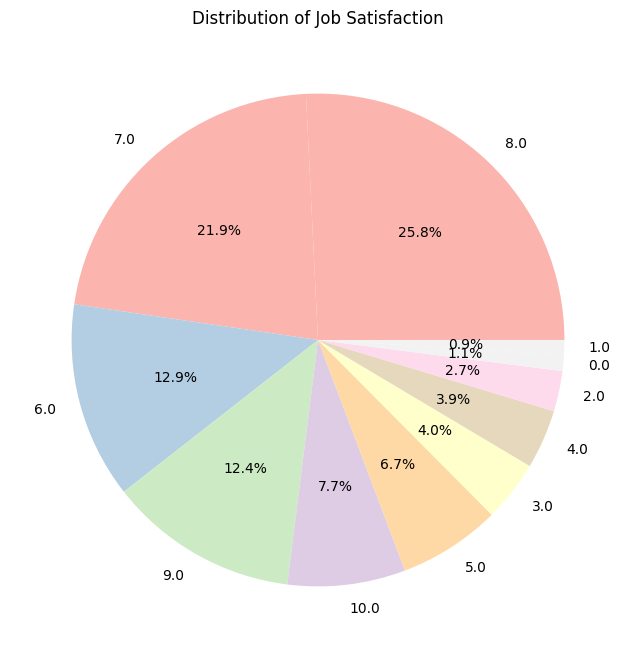

In [12]:
df['JobSat'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), cmap='Pastel1')
plt.title('Distribution of Job Satisfaction')
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


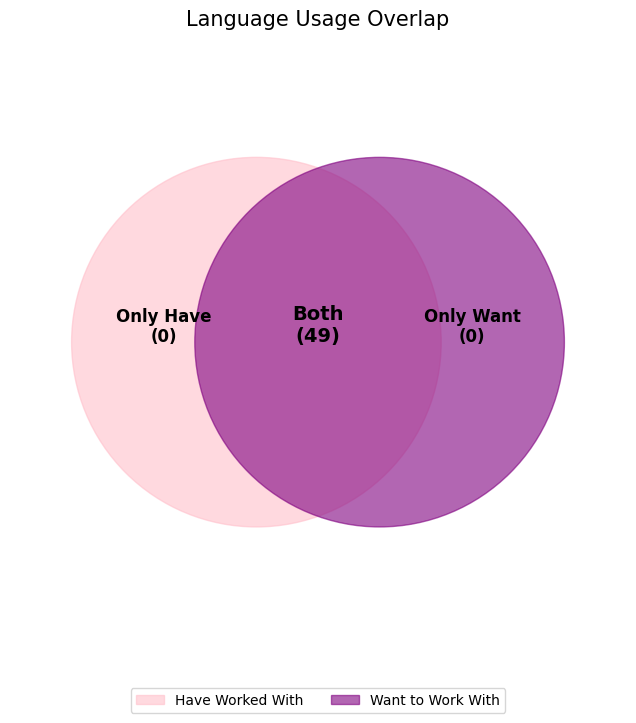

In [16]:
have_worked_set = set(df['LanguageHaveWorkedWith'].dropna().str.split(';').explode())
want_to_work_set = set(df['LanguageWantToWorkWith'].dropna().str.split(';').explode())
only_have = len(have_worked_set - want_to_work_set)
only_want = len(want_to_work_set - have_worked_set)
intersection = len(have_worked_set & want_to_work_set)
fig, ax = plt.subplots(figsize=(10, 8))
circle1 = plt.Circle((0.4, 0.5), 0.3, color='pink', alpha=0.6, label='Have Worked With')
circle2 = plt.Circle((0.6, 0.5), 0.3, color='purple', alpha=0.6, label='Want to Work With')
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
plt.text(0.25, 0.5, f"Only Have\n({only_have})", fontsize=12, ha='center', fontweight='bold')
plt.text(0.75, 0.5, f"Only Want\n({only_want})", fontsize=12, ha='center', fontweight='bold')
plt.text(0.5, 0.5, f"Both\n({intersection})", fontsize=14, ha='center', fontweight='bold')

plt.title("Language Usage Overlap", fontsize=15)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


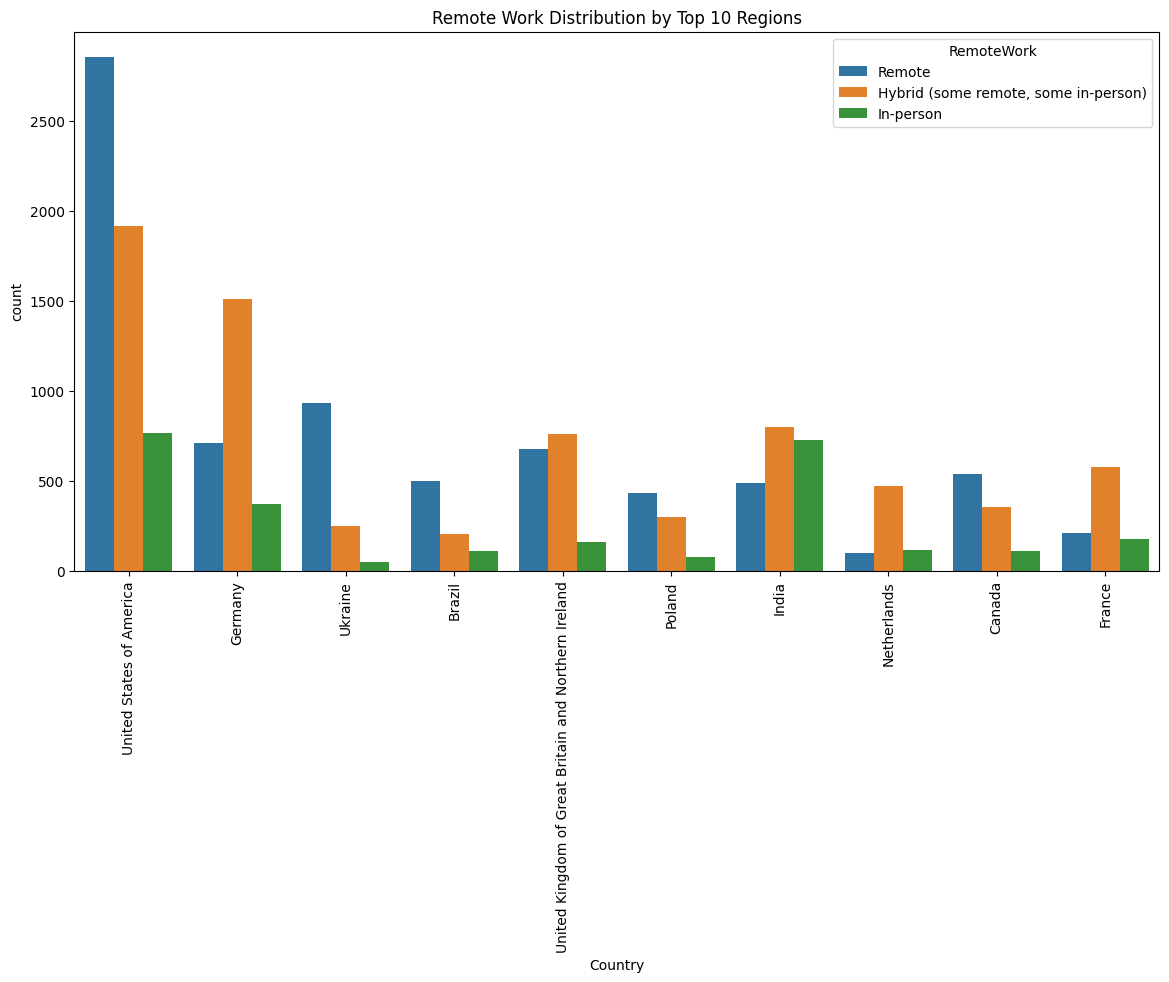

In [18]:
top_regions = df['Country'].value_counts().nlargest(10).index
df_filtered = df[df['Country'].isin(top_regions)]

plt.figure(figsize=(14, 7))
sns.countplot(data=df_filtered, x='Country', hue='RemoteWork')
plt.title('Remote Work Distribution by Top 10 Regions')
plt.xticks(rotation=90)
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [25]:
pearson_corr = corr_df['JobSat'].corr(corr_df['YearsCodePro'], method='pearson')
spearman_corr = corr_df['JobSat'].rank().corr(corr_df['YearsCodePro'].rank())
print(f"Pearson Correlation: {pearson_corr:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}")

Pearson Correlation: 0.1034
Spearman Correlation: 0.1207


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


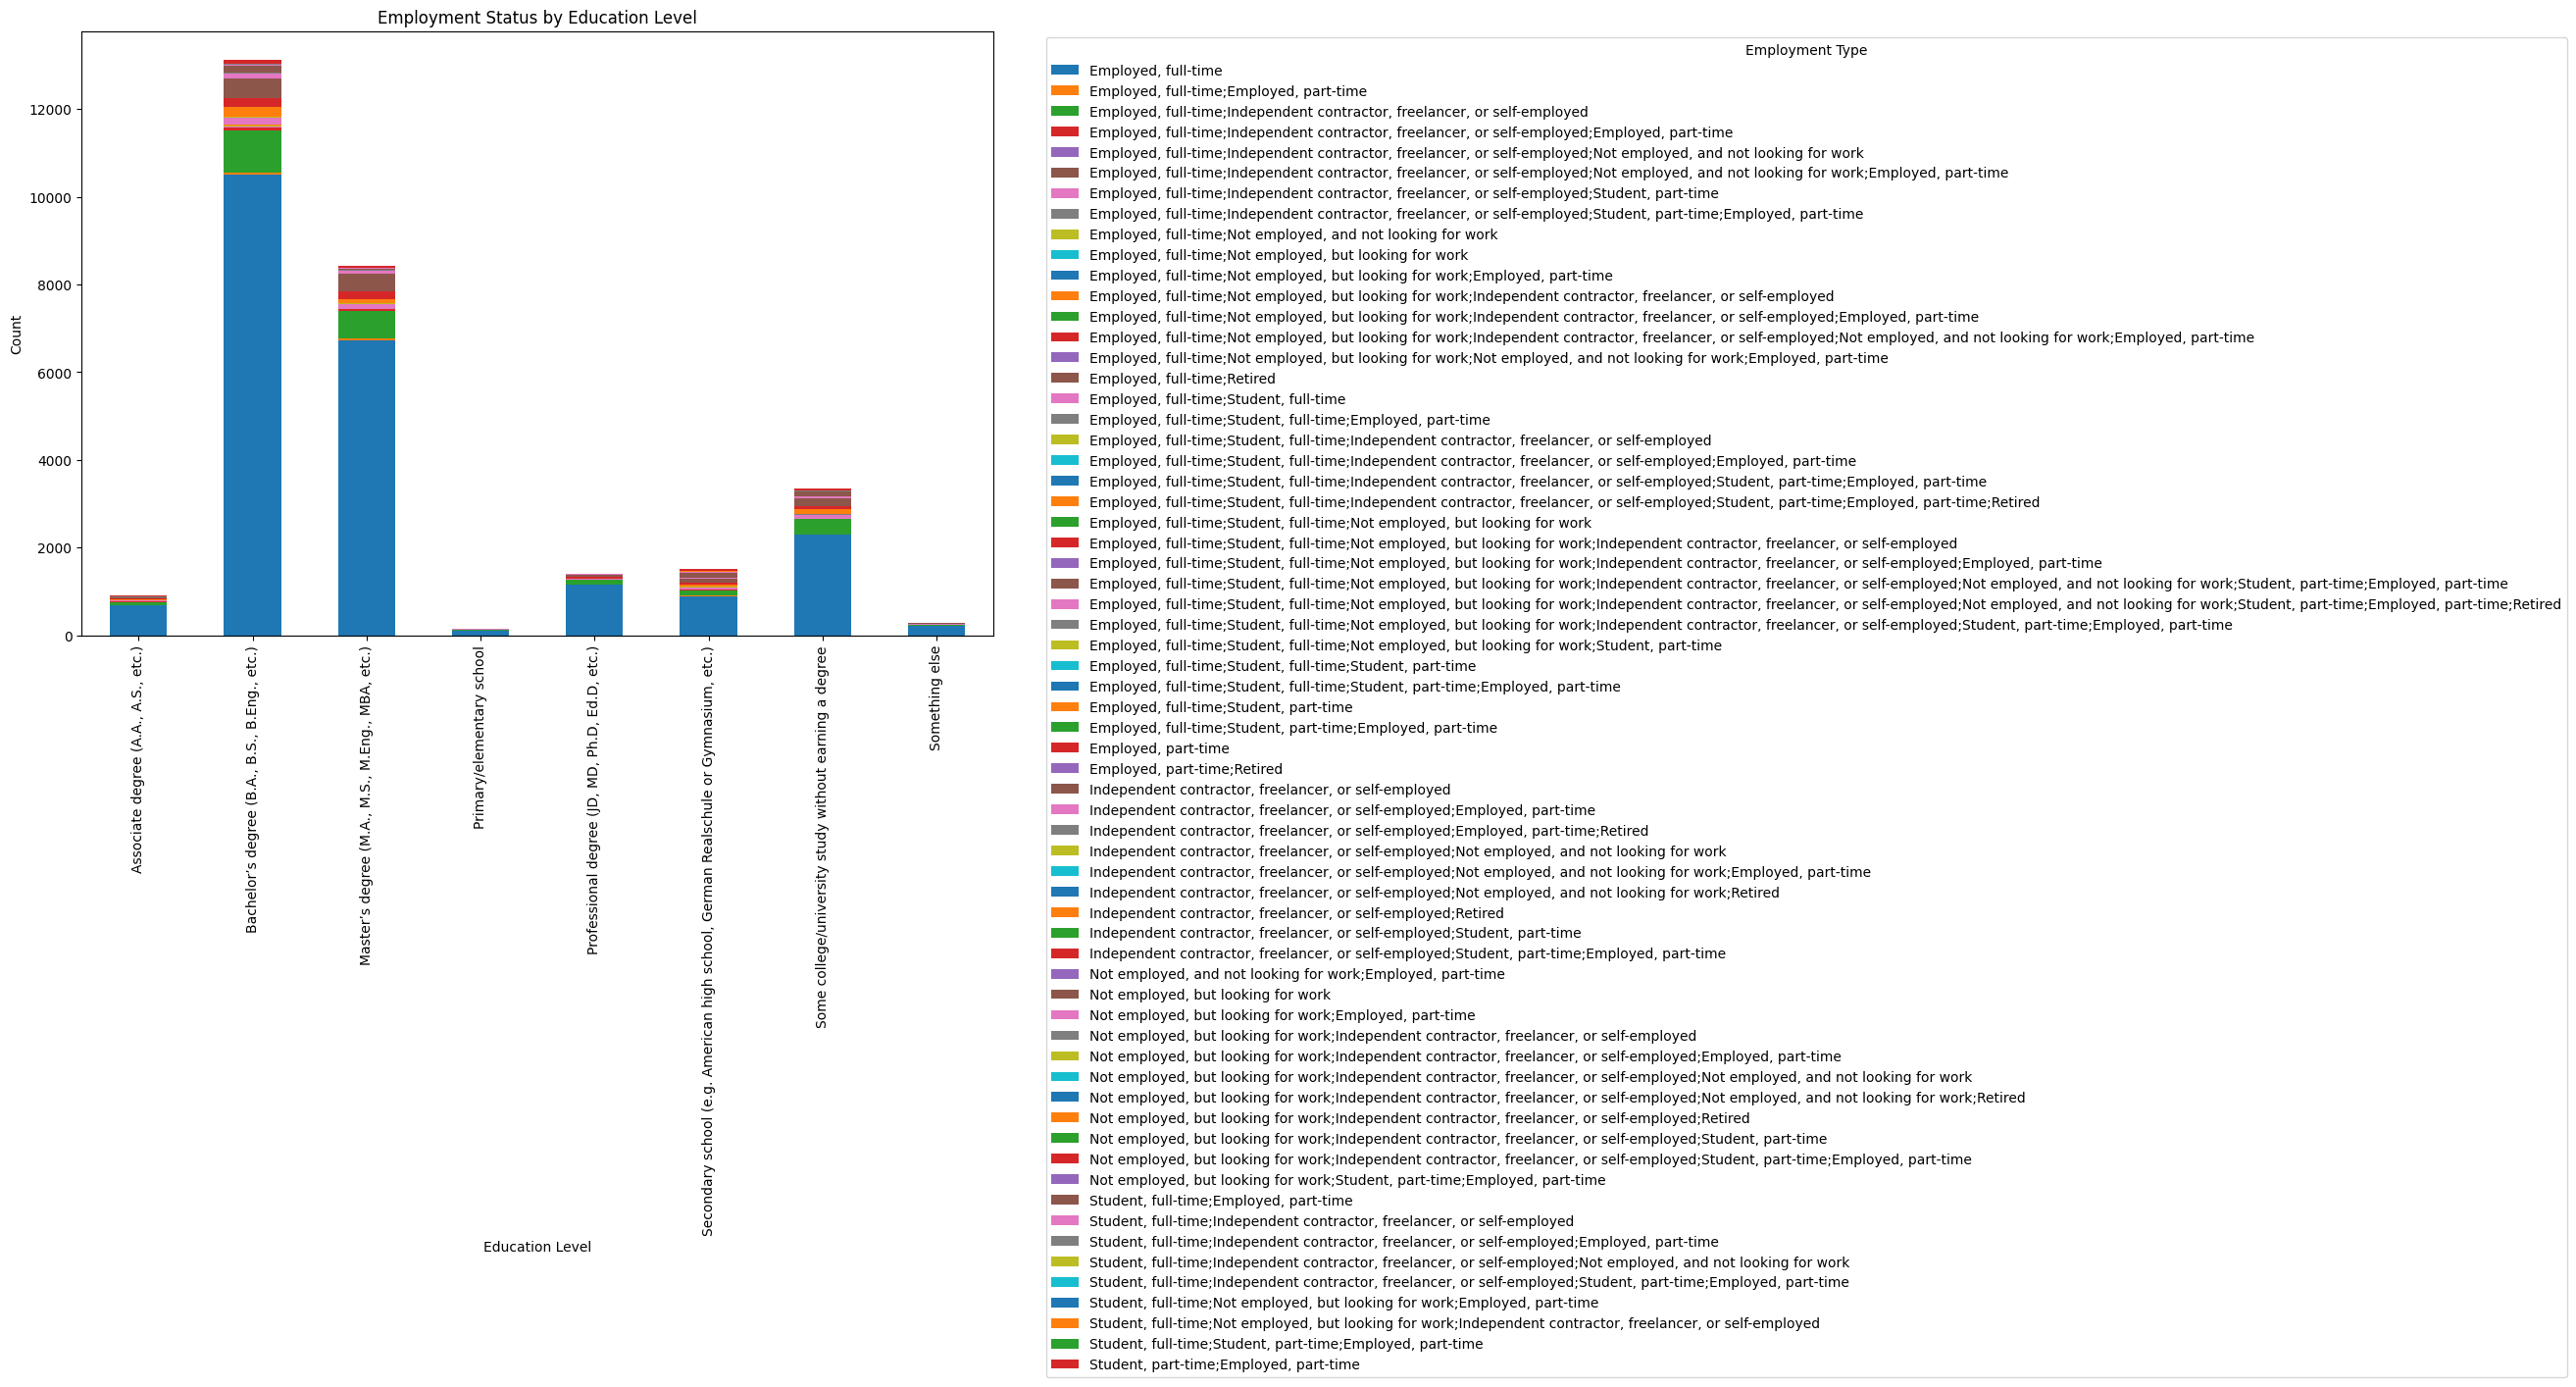

In [20]:
ct = pd.crosstab(df['EdLevel'], df['Employment'])
ct.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Employment Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [24]:
df.to_csv('Lab 11 finding how the data is distributed.csv', index=False)

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
